# 02 - Modelling and evaluation

Build a severity classifier (1-6) for triage: close (1-3) or investigate (4-6).

This notebook compares models, picks one, and shows the close/investigate rule.

Tables come from `reports/` (`severity-triage all`). See `models/run_manifest.json` for the run behind the prediction file.


In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

from severity_triage.config import load_settings
from severity_triage.models import MODEL_REGISTRY, REJECTED_ALTERNATIVES

pd.set_option("display.max_columns", 40); pd.set_option("display.width", 180); pd.set_option("display.precision", 4)
settings = load_settings()
R, F, TAG = settings.paths.reports_dir, settings.paths.figures_dir, settings.regime_tag

def table(name, index_col=None, **kw):
    return pd.read_csv(R / name, index_col=index_col, keep_default_na=False, na_values=[""], **kw)

def fig(name, width=900):
    display(Image(filename=str(F / name), width=width))

manifest = json.load(open(settings.paths.models_dir / "run_manifest.json"))
selection = json.load(open(settings.paths.models_dir / f"selection_{TAG}.json"))
print(f"run: {manifest['trained_at']} | seed {manifest['seed']} | regime {manifest['regime']} | model {manifest['model']['label']}")
print(f"CV: {settings.split.cv_repeats}x{settings.split.cv_folds} repeated stratified K-fold | tuning trials {settings.tuning.n_trials} for {settings.tuning.models}")
print(f"training rows {manifest['n_training_rows']} | holdback rows {manifest['n_holdback_rows']} | engineered features {manifest['n_features_engineered']}")

run: 2026-09-11T00:48:14+00:00 | seed 42 | regime A | model Proportional-odds (ordered) logit
CV: 3x5 repeated stratified K-fold | tuning trials 40 for ['xgboost', 'lightgbm']
training rows 2000 | holdback rows 500 | engineered features 82


## 1. Problem framing

Severity is ordered. Triage uses a cut at 4.

| Choice | Why |
|---|---|
| Quadratic weighted kappa (QWK) | Penalises big rank errors more than small ones |
| Severe-case recall | Missed severe cases are the costly error |
| Threshold on `P(severity >= 4)` | Sets the FN/FP trade-off (default 5:1) |

Also track MAE, macro-F1, and PR-AUC for the severe decision.


## 2. Validation design

- 20% holdout (400 cases) for final numbers only
- 3x5 repeated stratified CV on the rest for model comparison
- Impute/encode inside each fold
- Leak column removed before modelling

Holdback matches the training period, so a random stratified split is fine.


## 3. Baseline

Start simple and add one idea at a time, so we know what each step buys.


,rung,approach,qwk,mae,macro_f1,severe_recall,severe_precision,qwk_gain_vs_previous
0,0,Majority class (always predict 1),0.000,1.754,0.067,0.000,0.000,NaN
1,1,Single-feature rule on EstimatedImpactScore,0.920,0.313,0.697,0.900,0.877,0.920
2,2,"Logistic regression, raw columns only (44 feat...",0.941,0.261,0.713,0.925,0.893,0.020
3,3,"Logistic regression, engineered features (82 f...",0.936,0.279,0.698,0.917,0.895,-0.005
4,4,"Ordered logit, engineered features (ordinal st...",0.952,0.209,0.785,0.927,0.916,0.016
5,5,"LightGBM, engineered features (non-linear)",0.950,0.214,0.783,0.909,0.932,-0.002


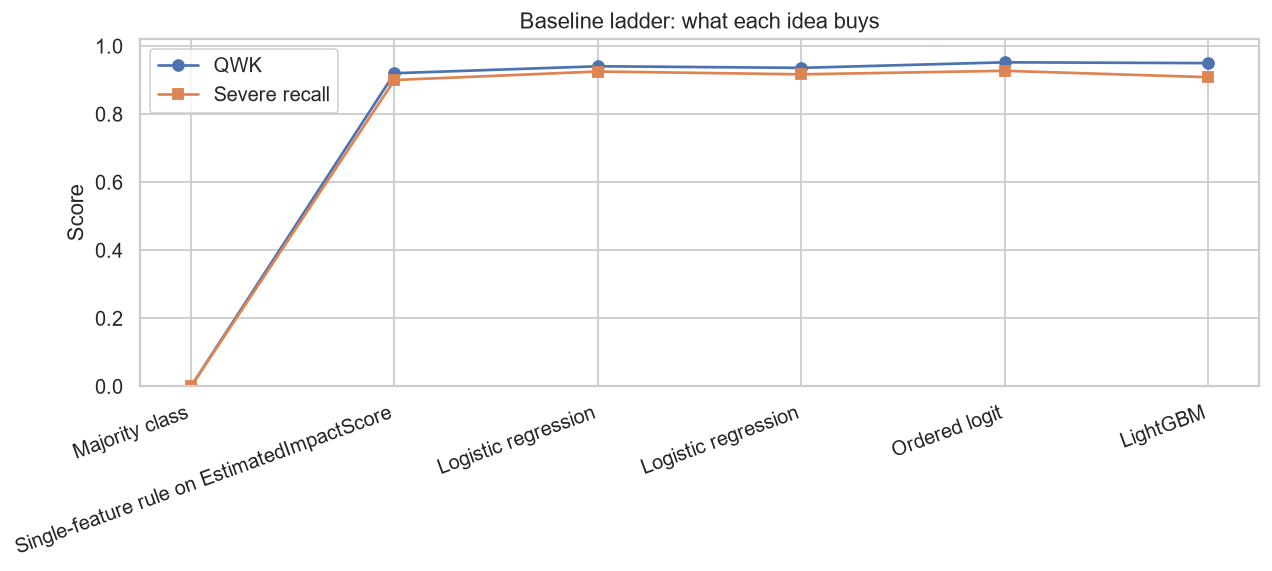

In [2]:
ladder = table(f"baseline_ladder_{TAG}.csv")
display(ladder[["rung", "approach", "qwk", "mae", "macro_f1", "severe_recall", "severe_precision", "qwk_gain_vs_previous"]].round(3))
fig(f"baseline_ladder_{TAG}.png", 800)

Takeaways:

- One rule on `EstimatedImpactScore` already gets high QWK
- Raw-feature logistic helps a bit more
- Ordinal structure helps more than extra features on a nominal linear model
- LightGBM does not beat ordered logit here


## 4. Models compared

Eight families plus a stacked ensemble. Details live in `src/severity_triage/models.py`.


In [3]:
rows = []
for name, fam in MODEL_REGISTRY.items():
    rows.append({"model": name, "label": fam.label, "ordinal_aware": fam.ordinal_aware, "complexity": fam.complexity,
                 "why chosen": fam.rationale, "trade-offs": fam.tradeoffs})
with pd.option_context("display.max_colwidth", 400):
    display(pd.DataFrame(rows).set_index("model"))

,label,ordinal_aware,complexity,why chosen,trade-offs
model,,,,,
logistic,Multinomial logistic regression,False,1,"Transparent linear baseline with well-calibrated probabilities. Coefficient signs give an immediate sanity check that the model has learned the domain direction (more impact, more severity).","Treats the six classes as unordered and cannot capture interactions without hand-crafted terms, so it sets the floor rather than the ceiling."
ordered_logit,Proportional-odds (ordered) logit,True,2,"The textbook model for an ordered outcome. One latent severity score plus five cut-points, so the ordering is built in and the cut-points are directly interpretable as the boundaries between severity bands.","Assumes a single slope vector across all thresholds (proportional odds) and is linear in the features, so it trails the boosted trees on raw accuracy."
frank_hall,Frank and Hall ordinal decomposition (HistGB base),True,6,"Decomposes the ordinal problem into five 'is severity above k?' questions answered by a gradient-boosted classifier each. Respects ordering, and the k=3 sub-model is exactly the triage decision the organisation makes.",Five models to train and explain instead of one; probabilities are reconstructed by differencing so they need a monotonicity fix-up.
regression_threshold,Regression with learned cut-points,True,5,"Treats severity as continuous, then learns the cut-points that maximise quadratic weighted kappa. Directly optimises the ordinal error structure and naturally penalises far-off predictions more than adjacent ones.","Class probabilities are approximate (Gaussian around the regression output) and the cut-points are tuned on out-of-fold data, which costs training time."
random_forest,Random forest,False,3,"Non-linear, low-tuning bagged baseline. Robust to outliers and monotone transforms, and provides an independent feature-importance view to cross-check the boosted models.","Probabilities tend to be under-confident, it is slower to score than boosting at equal accuracy, and it ignores class ordering."
hist_gb,Histogram gradient boosting (scikit-learn),False,4,"Strong tabular default with no extra dependency. Handles missing values natively, trains in seconds on two thousand rows and is easy to explain with SHAP.","Nominal multi-class objective, so nothing stops it confusing severity 1 with 6 at the same cost as 1 with 2."
xgboost,XGBoost,False,4,"The tabular workhorse. Mature regularisation, monotonic constraints for business-sensible directions, and an extensive tuning surface.","Requires 0-based labels and explicit sample weights, adding an adapter; heavier dependency than scikit-learn's own boosting."
lightgbm,LightGBM,False,4,"Leaf-wise boosting that trains fastest of the family and offers a second, differently-biased boosted view for the ensemble.","Leaf-wise growth overfits small data more readily than depth-wise, so num_leaves and min_child_samples need care."
stacked,Stacked ensemble,False,7,"Blends two boosted models, a nominal linear model and the ordinal logit through a logistic meta-learner fitted on out-of-fold probabilities, so it can only help where the base models disagree.",Several times the training cost and the least interpretable option; the gain over the best single model is usually small on data this size.


### Not used

Skipped options that did not fit this tabular ordinal problem well (e.g. heavy neural nets, plain accuracy-led AutoML).


In [4]:
with pd.option_context("display.max_colwidth", 500):
    display(pd.DataFrame({"reason not used": REJECTED_ALTERNATIVES}))

,reason not used
Multi-layer perceptron / deep tabular networks,"Two thousand rows is far below the regime where neural networks beat gradient boosting on tabular data, and they would cost interpretability on a criterion that carries explicit weight."
Support vector machine (RBF),"Probability outputs need a separate calibration step, there is no native handling of categoricals or missing values, and threshold tuning on poorly calibrated scores is exactly what the business risk criterion warns against."
k-nearest neighbours,"Distance becomes uninformative across 120 mixed-scale one-hot and numeric dimensions, and the model has no notion of class ordering."
Naive Bayes,"The independence assumption is violated by design: the impact, risk and remedy fields are tightly correlated restatements of the same latent severity."
TabPFN / AutoML frameworks,"Opaque model selection undermines the explainability and reasoning the assessment asks for; the value here is in showing the choices, not hiding them."
CatBoost,A strong candidate that would perform comparably to LightGBM and XGBoost. Excluded only to avoid a third near-identical boosted model; recorded as the first thing to try next.


## 5. Selection

Sort by CV QWK, then pick the simplest model within one standard error of the best (see `configs/base.yaml`).


,model,label,ordinal_aware,complexity,qwk,qwk_std,mae,macro_f1,severe_recall,severe_precision,severe_pr_auc,log_loss,fit_seconds
0,stacked,Stacked ensemble,False,7,0.9559,0.0040,0.1923,0.8035,0.9266,0.9331,0.9845,0.4913,625.1900
1,ordered_logit,Proportional-odds (ordered) logit,True,2,0.9538,0.0046,0.2033,0.7929,0.9342,0.9221,0.9846,0.4959,6.8718
2,random_forest,Random forest,False,3,0.9532,0.0046,0.1992,0.7916,0.9127,0.9440,0.9819,0.6457,64.1985
3,frank_hall,Frank and Hall ordinal decomposition (HistGB b...,True,6,0.9527,0.0049,0.2062,0.7896,0.9175,0.9224,0.9802,0.6348,451.9370
4,lightgbm_tuned,LightGBM (tuned),False,4,0.9525,0.0043,0.2046,0.7943,0.9203,0.9242,0.9791,0.5190,24.7683
5,xgboost_tuned,XGBoost (tuned),False,4,0.9513,0.0044,0.2100,0.7895,0.9113,0.9266,0.9789,0.5241,24.8033
6,lightgbm,LightGBM,False,4,0.9509,0.0050,0.2102,0.7860,0.9120,0.9337,0.9768,0.6709,68.5852
7,xgboost,XGBoost,False,4,0.9508,0.0052,0.2102,0.7865,0.9134,0.9329,0.9786,0.5638,100.6990
8,hist_gb,Histogram gradient boosting (scikit-learn),False,4,0.9504,0.0046,0.2121,0.7834,0.9071,0.9323,0.9760,0.6921,289.9000
9,regression_threshold,Regression with learned cut-points,True,5,0.9497,0.0027,0.2219,0.7754,0.9238,0.9009,0.9788,0.5521,426.1830


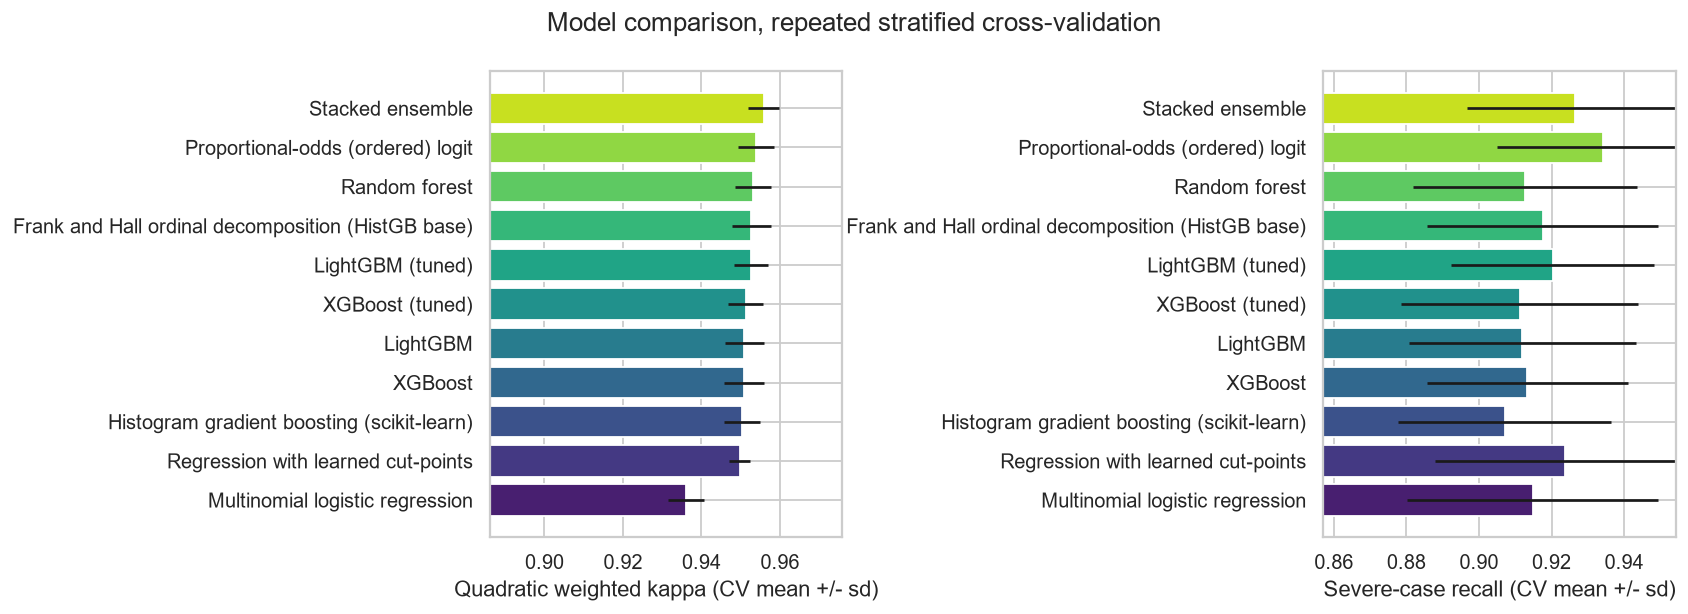

**Selected:** `ordered_logit`  
one-standard-error rule with practical-equivalence floor: tolerance 0.0050 = max(1 x SE 0.0010, 0.005); 7 of 11 models score within it of the best (stacked, qwk=0.9559); ordered_logit is the simplest of them (qwk=0.9538, complexity 2 vs 7)

In [5]:
comp = table(f"model_comparison_{TAG}.csv")
cols = ["model", "label", "ordinal_aware", "complexity", "qwk", "qwk_std", "mae", "macro_f1", "severe_recall", "severe_precision", "severe_pr_auc", "log_loss", "fit_seconds"]
display(comp[cols].round(4))
fig(f"model_comparison_{TAG}.png", 1000)
display(Markdown(f"**Selected:** `{selection['selected']}`  \n{selection['selection_reasoning']}"))

Most models sit close together on QWK.

**Ordered logit** is selected: near the top, best severe recall among single models, fast, and easy to explain.

The stacked ensemble is slightly higher but within noise and much heavier.


## 6. Tuning

Optuna on the boosted models to check if defaults were underdone.


lightgbm   trials= 40  best CV QWK=0.9531  (trial 7, severe recall 0.921)


,number,cv_qwk,params_colsample_bytree,params_learning_rate,params_min_child_samples,params_n_estimators,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,cv_severe_recall,duration,best_so_far
7,7,0.9531,0.6357,0.0180,16,250,9,0.0209,4.5444,0.7555,0.9210,0 days 00:00:05.920987,0.9531
30,30,0.9526,0.6071,0.0109,25,300,32,0.0025,3.6134,0.6331,0.9148,0 days 00:00:11.102914,0.9531
16,16,0.9525,0.6714,0.0114,22,350,35,0.0048,3.5392,0.6313,0.9168,0 days 00:00:13.816101,0.9531
33,33,0.9525,0.6769,0.0124,24,300,34,0.0046,2.3159,0.6573,0.9127,0 days 00:00:11.415933,0.9531
29,29,0.9525,0.5417,0.0146,21,350,20,0.0159,7.3875,0.7075,0.9148,0 days 00:00:15.160345,0.9531


xgboost    trials= 37  best CV QWK=0.9532  (trial 29, severe recall 0.911)


,number,cv_qwk,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,cv_severe_recall,duration,best_so_far
29,29,0.9532,0.9563,0.0372,2,3,200,0.0039,2.0646,0.6964,0.9106,0 days 00:00:10.918891,0.9532
28,28,0.9527,0.9985,0.0342,2,5,250,0.0042,5.1727,0.6862,0.9085,0 days 00:00:14.123644,0.9527
33,33,0.9523,0.9655,0.0289,2,3,300,0.0061,0.8149,0.6942,0.9127,0 days 00:00:11.748161,0.9532
21,21,0.9520,0.9500,0.0417,2,6,350,0.0179,2.1006,0.7557,0.9210,0 days 00:00:17.108380,0.9520
5,5,0.9520,0.8313,0.0441,2,10,250,0.0839,0.4202,0.7035,0.9148,0 days 00:00:12.701953,0.9520


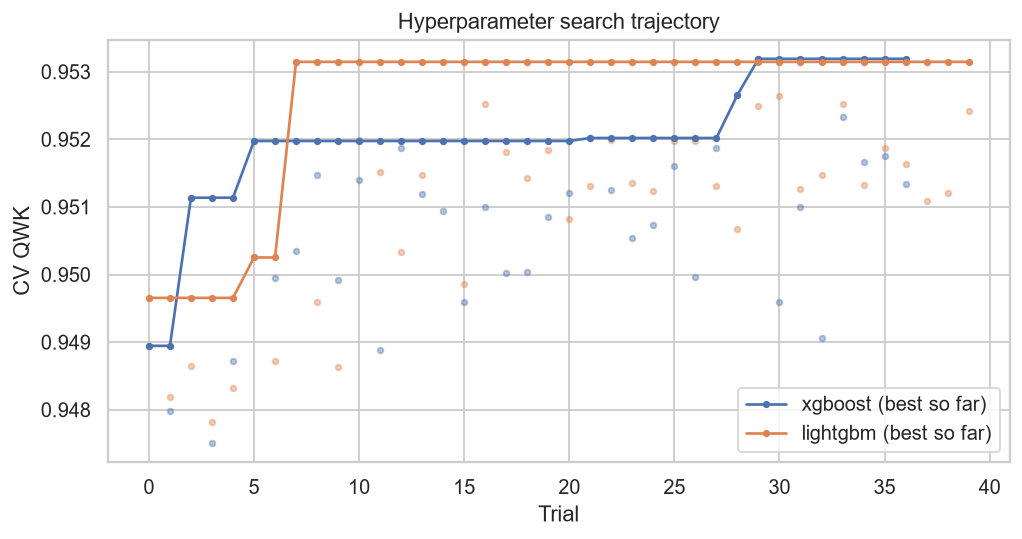

,model,qwk,qwk_std,severe_recall
4,lightgbm_tuned,0.9525,0.0043,0.9203
5,xgboost_tuned,0.9513,0.0044,0.9113


In [6]:
import glob, os
traj = {}
for path in sorted(glob.glob(str(R / f"tuning_*_{TAG}.csv"))):
    name = os.path.basename(path).replace(f"_{TAG}.csv", "").replace("tuning_", "")
    t = pd.read_csv(path); traj[name] = t
    best = t.loc[t["cv_qwk"].idxmax()]
    print(f"{name:10s} trials={len(t):3d}  best CV QWK={best['cv_qwk']:.4f}  (trial {int(best['number'])}, severe recall {best['cv_severe_recall']:.3f})")
    display(t.sort_values("cv_qwk", ascending=False).head(5).round(4))
if (F / f"tuning_trajectory_{TAG}.png").exists():
    fig(f"tuning_trajectory_{TAG}.png", 800)
tuned = comp[comp["model"].str.endswith("_tuned")]
display(tuned[["model", "qwk", "qwk_std", "severe_recall"]].round(4))

Tuning only moves QWK by a tiny amount. Defaults were already fine.


## 7. Holdout results

Final scores on the untouched 400-case test set.


,qwk,mae,macro_f1,balanced_accuracy,accuracy,exact_or_adjacent,severe_recall,severe_precision,severe_f1,severe_missed,non_severe_progressed,severe_roc_auc,severe_pr_auc,severe_brier,log_loss
internal test set (argmax),0.9567,0.19,0.8157,0.8279,0.8125,0.9975,0.95,0.912,0.9306,6.0,11.0,0.9943,0.987,0.0295,0.4596


,recall_1,recall_2,recall_3,recall_4,recall_5,recall_6
per-class recall,0.931,0.765,0.728,0.763,0.78,1.0


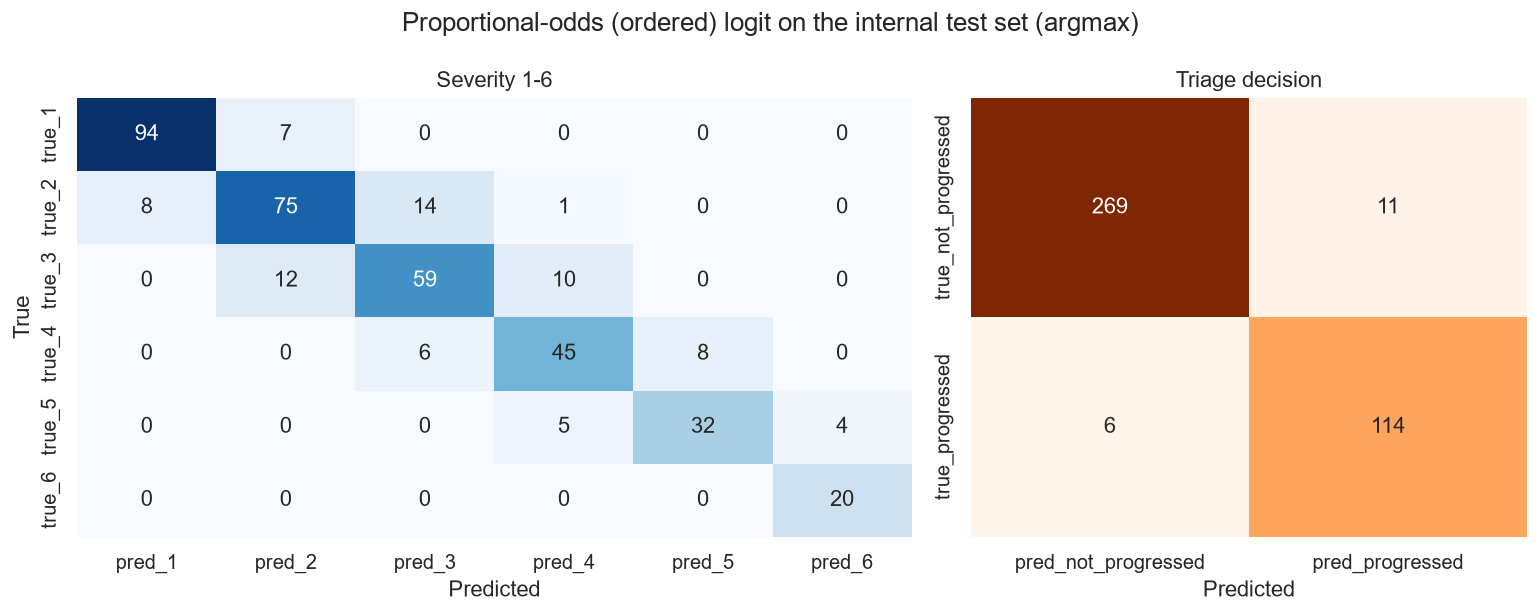

,count,share
exact,325,0.8125
under_by_1,31,0.0775
over_by_1,43,0.1075
under_by_2_or_more,0,0.0000
over_by_2_or_more,1,0.0025
crossed_boundary_downwards (severe -> not),6,0.0150
crossed_boundary_upwards (not -> severe),11,0.0275


In [7]:
hold = table(f"holdout_metrics_{TAG}.csv", index_col=0)["value"]
show = ["qwk", "mae", "macro_f1", "balanced_accuracy", "accuracy", "exact_or_adjacent",
        "severe_recall", "severe_precision", "severe_f1", "severe_missed", "non_severe_progressed",
        "severe_roc_auc", "severe_pr_auc", "severe_brier", "log_loss"]
display(hold.loc[show].round(4).to_frame("internal test set (argmax)").T)
display(hold.loc[[f"recall_{c}" for c in range(1, 7)]].round(3).to_frame("per-class recall").T)
fig(f"confusion_{TAG}.png", 1000)
display(table(f"error_analysis_{TAG}.csv", index_col=0))

Most errors are off by one level. The triage risk is crossing the 3/4 line. Section 9 handles that with the cost threshold.


## 8. Calibration

The triage rule uses `P(severity >= 4)`, so that probability should be trustworthy.


,variant,severe_brier,log_loss
0,uncalibrated,0.0295,0.4596
1,isotonic,0.0294,0.5276


,bin,n,mean_predicted,observed_rate,gap
0,0,251,0.006,0.000,-0.006
1,1,6,0.143,0.167,0.024
2,2,7,0.253,0.286,0.033
3,3,8,0.342,0.125,-0.217
4,4,3,0.432,0.667,0.234
5,6,5,0.637,0.200,-0.437
6,7,5,0.758,0.400,-0.358
7,8,10,0.858,0.800,-0.058
8,9,105,0.988,0.981,-0.007


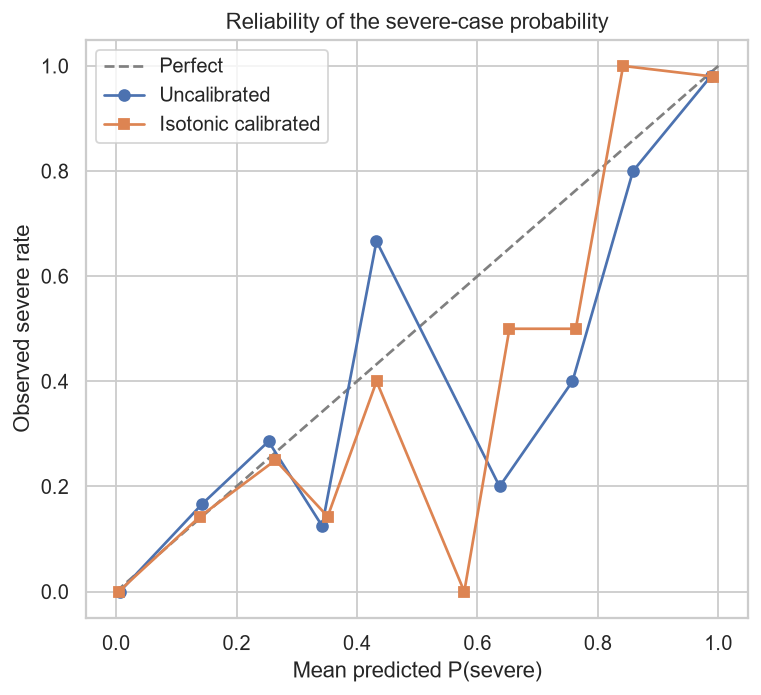

In [8]:
display(table(f"calibration_summary_{TAG}.csv").round(4))
display(table(f"calibration_uncalibrated_{TAG}.csv").round(3))
fig(f"calibration_{TAG}.png", 520)

Ordered logit is already well calibrated. No extra calibration step is applied.


## 9. Triage decision

The brief says missing a severe case is worse than reviewing a mild one. We set that as FN:FP = 5:1 and pick the threshold on out-of-fold training probabilities.


,cost_ratio,threshold,severe_recall,severe_precision,progressed_share,expected_cost_per_case
0,3,0.23,0.977,0.856,0.343,0.070
1,5,0.17,0.985,0.836,0.354,0.080
2,10,0.08,0.994,0.797,0.375,0.095


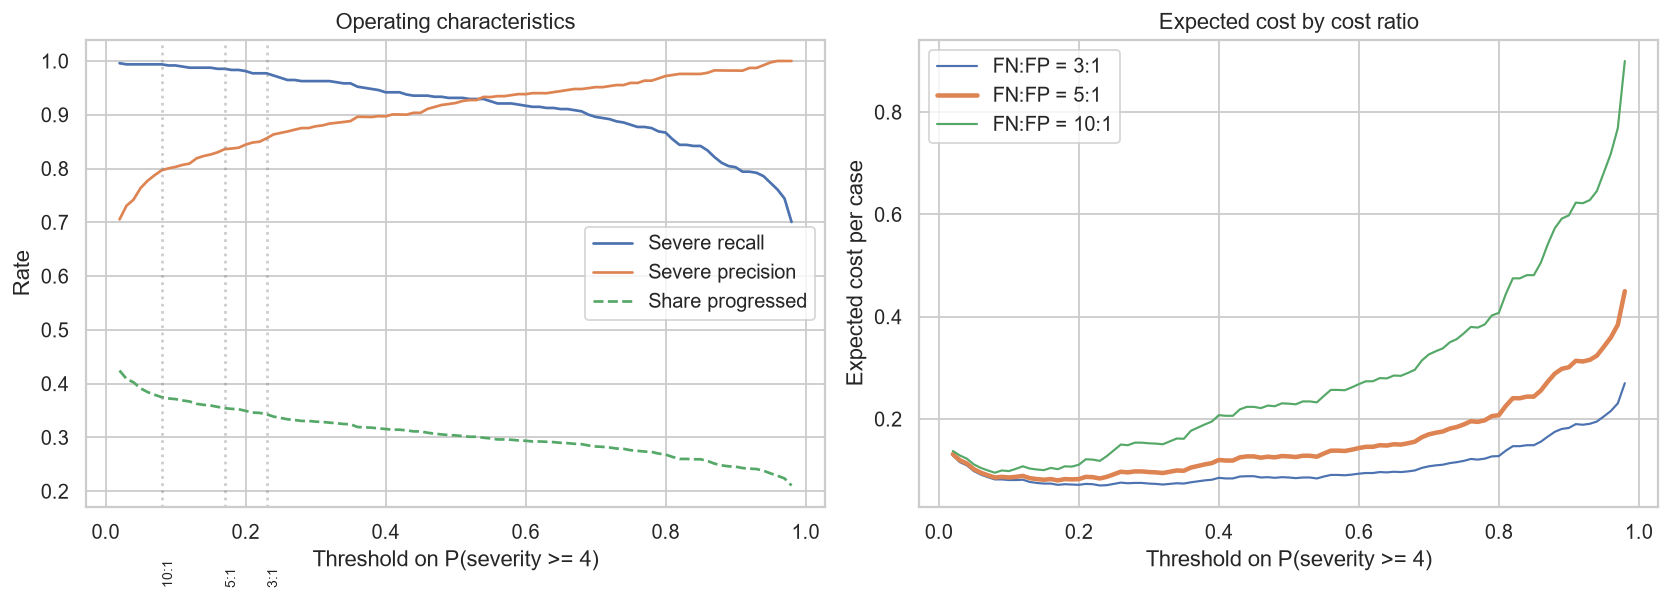

,rule,qwk,macro_f1,severe_recall,severe_precision,severe_missed,non_severe_progressed
0,argmax (threshold 0.5-equivalent),0.957,0.816,0.950,0.912,6,11
1,cost-optimal threshold 0.17 (FN:FP 5:1),0.952,0.792,0.992,0.821,1,26


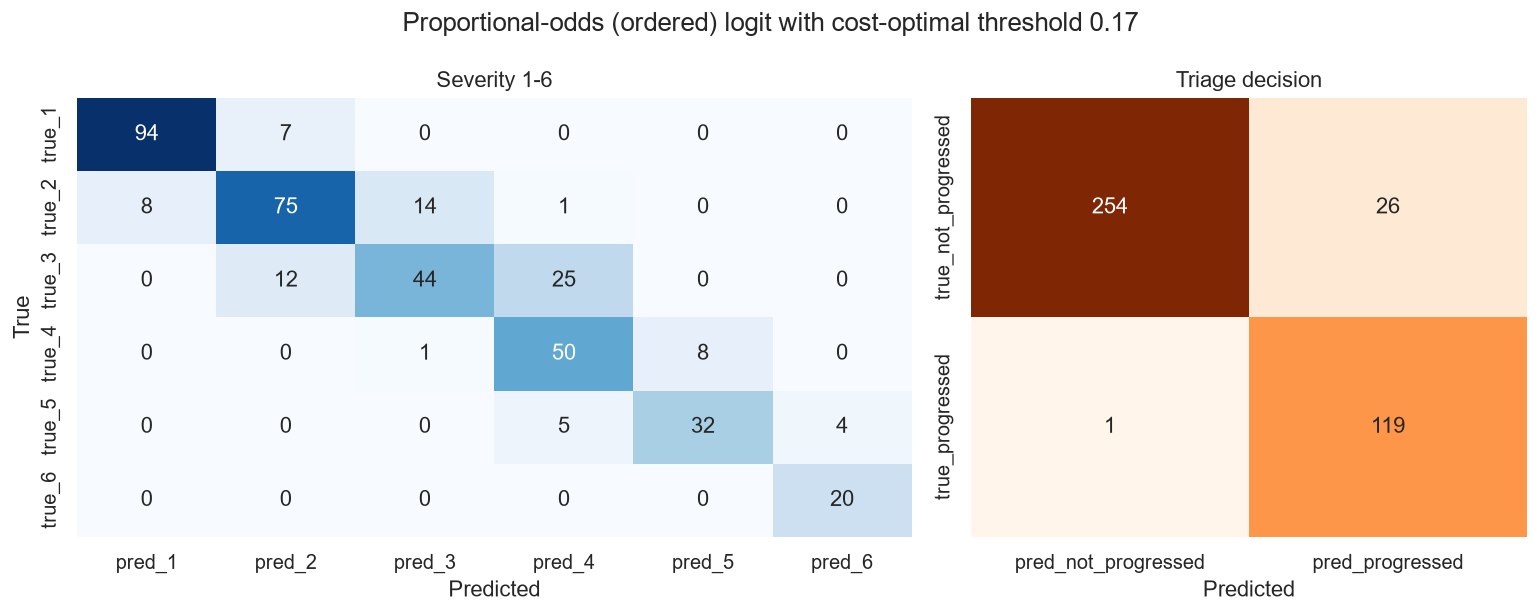

In [9]:
ops = table(f"operating_points_{TAG}.csv")
display(ops.round(3))
fig(f"threshold_sweep_{TAG}.png", 1000)
display(table(f"decision_rule_comparison_{TAG}.csv").round(3))
fig(f"confusion_cost_aware_{TAG}.png", 1000)

Reading the decision results:

- At 5:1 the threshold sits well below 0.5
- On the test set, severe misses drop a lot; more mild cases get reviewed
- 3:1 and 10:1 are shown for sensitivity
- In the prediction file, `PredictedSeverityScore >= 4` matches the progress decision


## 10. Capacity view

If only a fixed share of cases can be investigated, rank by `P_Severe` and take the top N.


,capacity_fraction,cases_progressed,implied_threshold,severe_recall,severe_precision,severe_missed
0,0.25,100,0.930,0.817,0.980,22
1,0.30,120,0.731,0.942,0.942,7
2,0.35,140,0.256,0.975,0.836,3
3,0.40,160,0.063,1.000,0.750,0


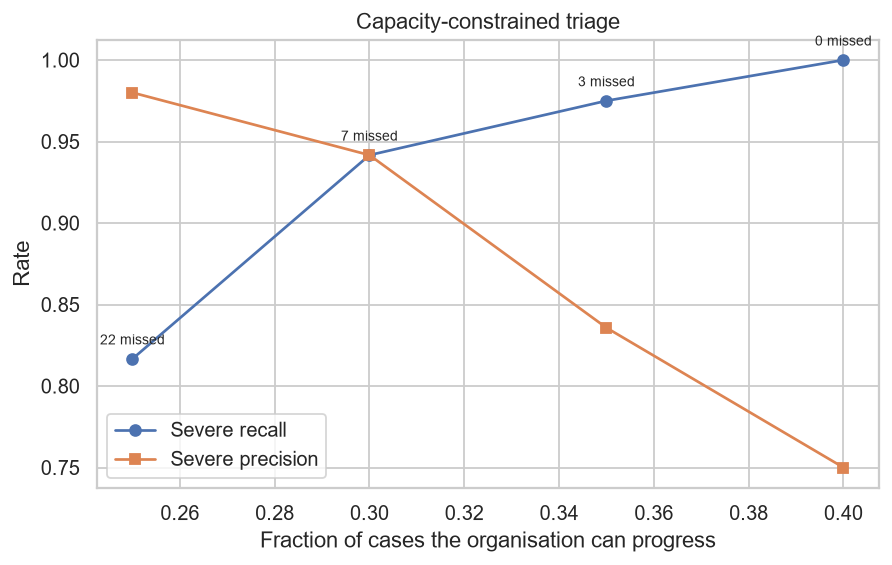

In [10]:
display(table(f"capacity_analysis_{TAG}.csv").round(3))
fig(f"capacity_{TAG}.png", 620)

## 11. Robustness

### 11a. Feature ablation

Drop one feature block at a time and re-check CV.


,dropped_group,n_features,qwk,severe_recall,macro_f1,delta_qwk,delta_severe_recall
0,(none),82,0.9523,0.9273,0.7850,0.0000,0.0000
1,raw_numeric,69,0.9533,0.9273,0.7919,0.0010,0.0000
2,ordinal_codes,77,0.9524,0.9232,0.7880,0.0001,-0.0041
3,boolean_flags,69,0.9529,0.9231,0.7875,0.0007,-0.0042
4,nominal,74,0.9550,0.9335,0.7980,0.0028,0.0062
5,date_parts,77,0.9535,0.9273,0.7882,0.0013,0.0000
6,composite_financial,75,0.9503,0.9232,0.7773,-0.0020,-0.0041
7,composite_impact,76,0.9516,0.9315,0.7860,-0.0006,0.0042
8,composite_vulnerability,80,0.9540,0.9314,0.7927,0.0018,0.0041
9,composite_failure,79,0.9531,0.9252,0.7902,0.0008,-0.0021


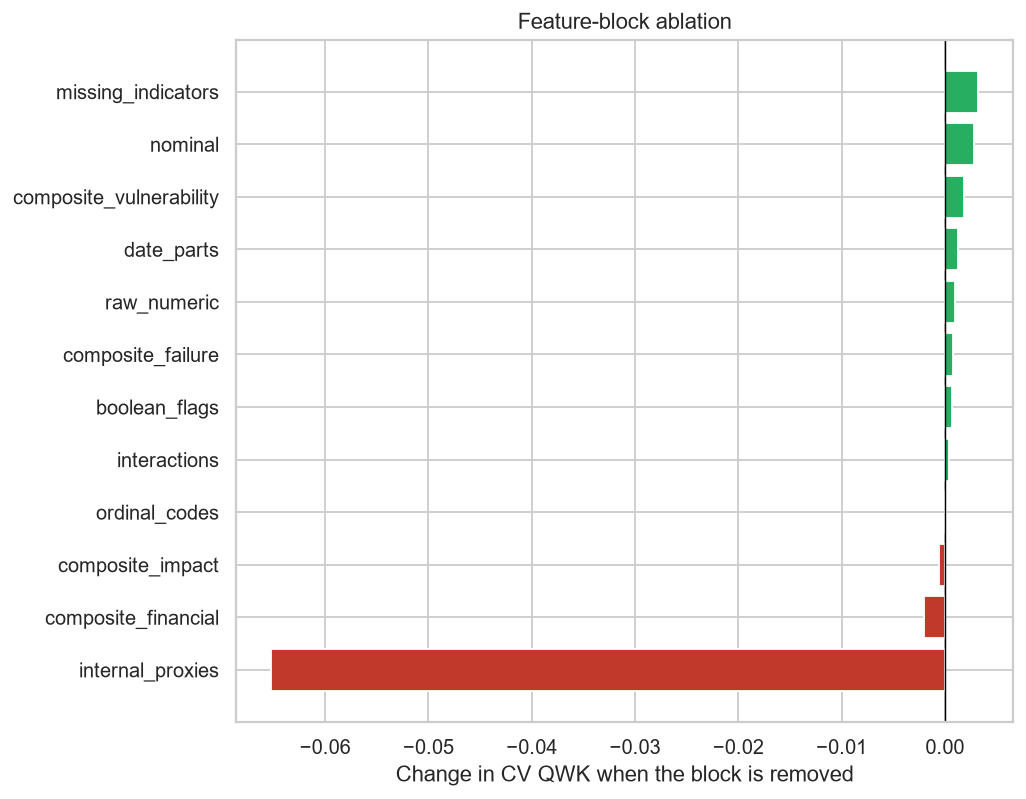

In [11]:
display(table(f"ablation_{TAG}.csv").round(4))
fig(f"ablation_{TAG}.png", 700)

### 11b. Regime A vs B

Regime A keeps internal scores. Regime B drops them to measure dependence.


In [12]:
display(table(f"regime_comparison_{selection['family']}.csv").round(4))

,regime,n_features,qwk,mae,macro_f1,severe_recall,severe_pr_auc
0,A,82,0.9538,0.2033,0.7929,0.9342,0.9846
1,B,76,0.8879,0.4408,0.5776,0.8801,0.9319


Regime B is still usable (QWK ~0.89) but clearly below Regime A. Submitted predictions use Regime A.

### 11c. Missing data and noise

Blank cells and noise checks show how performance drops when inputs get messier.


,missing_fraction,qwk,macro_f1,severe_recall,severe_pr_auc
0,0.0,0.957,0.816,0.950,0.987
1,0.1,0.937,0.765,0.908,0.980
2,0.2,0.916,0.681,0.850,0.968
3,0.3,0.865,0.595,0.708,0.955


,noise_scale,qwk,macro_f1,severe_recall,severe_pr_auc
0,0.0,0.957,0.816,0.950,0.987
1,0.1,0.951,0.775,0.950,0.985
2,0.2,0.943,0.749,0.925,0.979
3,0.5,0.918,0.653,0.925,0.954


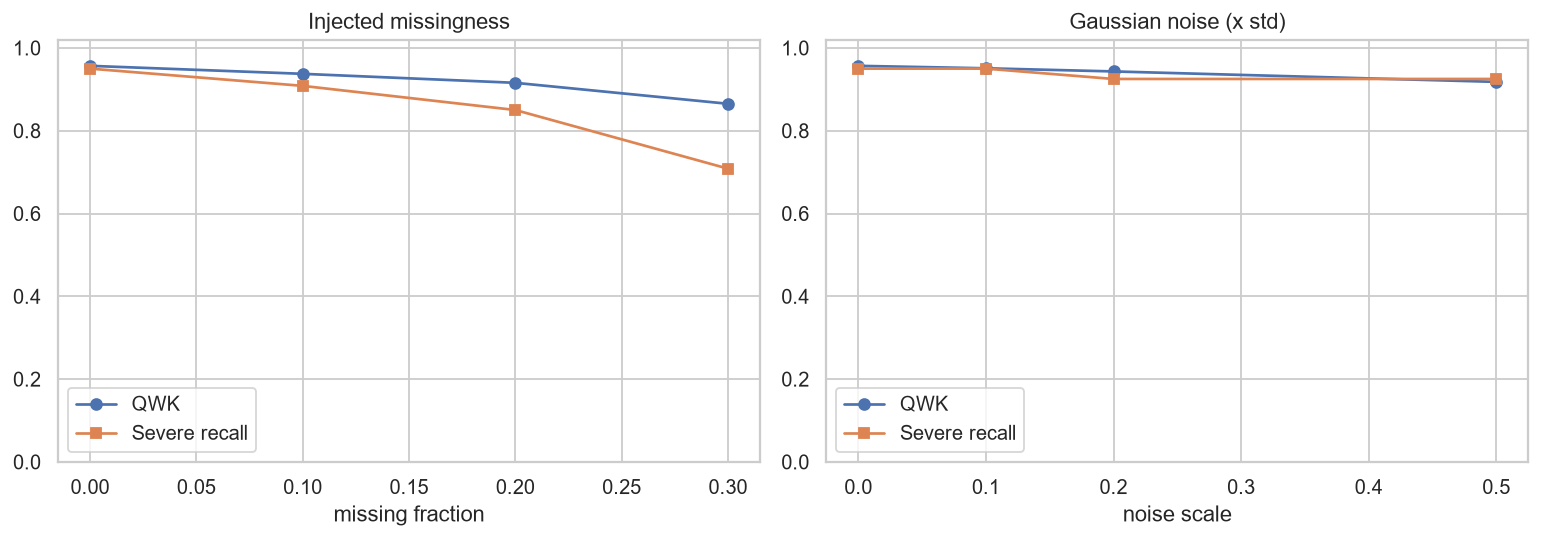

In [13]:
display(table(f"robustness_missingness_{TAG}.csv").round(3))
display(table(f"robustness_noise_{TAG}.csv").round(3))
fig(f"robustness_{TAG}.png", 1000)

### 11d. Subgroups

Severe recall/precision by jurisdiction, age band, vulnerability, organisation type.


In [14]:
sub = table(f"subgroup_performance_{TAG}.csv")
display(sub.round(3))
print("Minimum severe recall across subgroups:", sub["severe_recall"].min())

,column,level,n,severe_rate,severe_recall,severe_precision,qwk
0,Jurisdiction,Health,246,0.317,0.987,0.846,0.961
1,Jurisdiction,Parliamentary,135,0.281,1.000,0.792,0.945
2,AgeBand,18-34,73,0.274,0.950,0.864,0.932
3,AgeBand,35-49,93,0.333,1.000,0.816,0.937
4,AgeBand,50-64,94,0.298,1.000,0.800,0.960
5,AgeBand,65-79,75,0.240,1.000,0.857,0.974
6,AgeBand,80+,51,0.333,1.000,0.773,0.954
7,PrimaryVulnerability,(missing),20,0.200,1.000,0.800,0.943
8,PrimaryVulnerability,Caring Responsibilities,37,0.297,1.000,0.917,0.963
9,PrimaryVulnerability,Financial Hardship,46,0.370,1.000,0.850,0.943


Minimum severe recall across subgroups: 0.95


## 12. Live check

Fit the selected model on the training portion and score a few holdback rows.


In [15]:
from severity_triage.pipeline import load_bundle
from severity_triage.models import make_pipeline
from severity_triage.decision import cost_aware_predict
from severity_triage.evaluation import p_severe

bundle = load_bundle(settings)
train_idx, test_idx = bundle.split(settings)
pipe = make_pipeline(selection["family"], bundle.spec, settings.project.seed)
if selection["params"]:
    pipe.set_params(**selection["params"])
pipe.fit(bundle.X.loc[train_idx], bundle.y.loc[train_idx].to_numpy())

threshold = manifest["decision"]["threshold"]
sample = bundle.X_holdback.head(5)
proba = pipe.predict_proba(sample)
argmax, adjusted, progress = cost_aware_predict(proba, pipe.classes_, severe_from=4, threshold=threshold)
demo = pd.DataFrame({
    "CaseReference": bundle.holdback_clean["CaseReference"].head(5).to_numpy(),
    "P_severe": p_severe(proba, list(pipe.classes_), 4).round(3),
    "argmax": argmax, "adjusted_severity": adjusted,
    "decision": np.where(progress, "progress", "close"),
})
for k, c in enumerate(pipe.classes_):
    demo[f"P{c}"] = proba[:, k].round(3)
display(demo)
print(f"threshold {threshold:.2f} at FN:FP {manifest['decision']['cost_ratio']:g}:1")

,CaseReference,P_severe,argmax,adjusted_severity,decision,P1,P2,P3,P4,P5,P6
0,HLD-000001,1.000,5,5,progress,0.000,0.000,0.000,0.004,0.772,0.224
1,HLD-000002,1.000,5,5,progress,0.000,0.000,0.000,0.180,0.815,0.005
2,HLD-000003,0.000,1,1,close,0.992,0.008,0.000,0.000,0.000,0.000
3,HLD-000004,0.085,3,3,close,0.000,0.017,0.899,0.085,0.000,0.000
4,HLD-000005,0.978,4,4,progress,0.000,0.000,0.022,0.921,0.057,0.000


threshold 0.19 at FN:FP 5:1


## 13. Summary

- **Model:** ordered logit, 82 features (Regime A)
- **Holdout:** QWK ~0.96; cost-aware severe recall ~0.99
- **Trade-off:** a bit more cases progressed than the 30% base rate
- **Dependency:** internal impact/risk scores matter a lot; Regime B documents the gap

Notebook 03 covers explanations and residual risks.
